# Hardware Experiment: Live MPU6050 — no-DP vs CDP (nm=1.0)
FedProx + 1D-CNN + MPU6050 live data (80/20 split, 200 rounds)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120
})

In [11]:
# Load both result files
# Adjust paths if needed
nodp = pd.read_csv('../hardware_exp/hardware_live_noDP_r200_full.csv')
cdp  = pd.read_csv('../hardware_exp/hardware_live_CDP_nm1_r200_full.csv')

print('no-DP shape:', nodp.shape)
print('CDP   shape:', cdp.shape)
nodp.head(3)

no-DP shape: (200, 7)
CDP   shape: (200, 7)


,round,accuracy,f1,fit_wall_s,cpu_pct,memory_usage_mb,noise_multiplier
0,1,0.6333,0.6062,0.92,84.5,420.0,0.0
1,2,0.8167,0.8198,0.91,84.5,420.0,0.0
2,3,0.8167,0.8168,0.91,84.5,420.0,0.0


In [8]:
# Smoothing helper (rolling average)
def smooth(series, window=10):
    return series.rolling(window=window, min_periods=1, center=True).mean()

## 1. Accuracy vs Communication Rounds

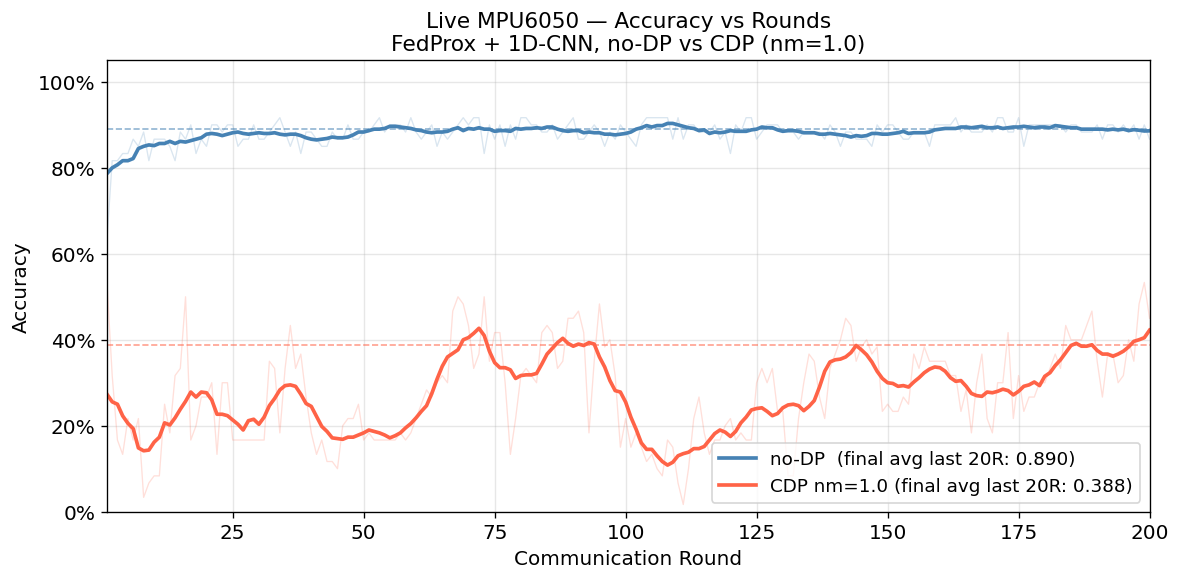

Saved: ../hardware_exp/plot_live_accuracy_nodp_vs_cdp.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

rounds = nodp['round']

# Raw lines (light)
ax.plot(rounds, nodp['accuracy'], color='steelblue', alpha=0.2, linewidth=0.8)
ax.plot(cdp['round'], cdp['accuracy'], color='tomato', alpha=0.2, linewidth=0.8)

# Smoothed lines
ax.plot(rounds, smooth(nodp['accuracy']), color='steelblue', linewidth=2.2,
        label=f'no-DP  (final avg last 20R: {nodp["accuracy"].tail(20).mean():.3f})')
ax.plot(cdp['round'], smooth(cdp['accuracy']), color='tomato', linewidth=2.2,
        label=f'CDP nm=1.0 (final avg last 20R: {cdp["accuracy"].tail(20).mean():.3f})')

# Annotations
ax.axhline(nodp['accuracy'].tail(20).mean(), color='steelblue', linestyle='--',
           linewidth=1, alpha=0.6)
ax.axhline(cdp['accuracy'].tail(20).mean(), color='tomato', linestyle='--',
           linewidth=1, alpha=0.6)

ax.set_xlabel('Communication Round')
ax.set_ylabel('Accuracy')
ax.set_title('Live MPU6050 — Accuracy vs Rounds\nFedProx + 1D-CNN, no-DP vs CDP (nm=1.0)')
ax.set_xlim(1, 200)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../hardware_exp/plot_live_accuracy_nodp_vs_cdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../hardware_exp/plot_live_accuracy_nodp_vs_cdp.png')

## 2. F1-Score vs Communication Rounds

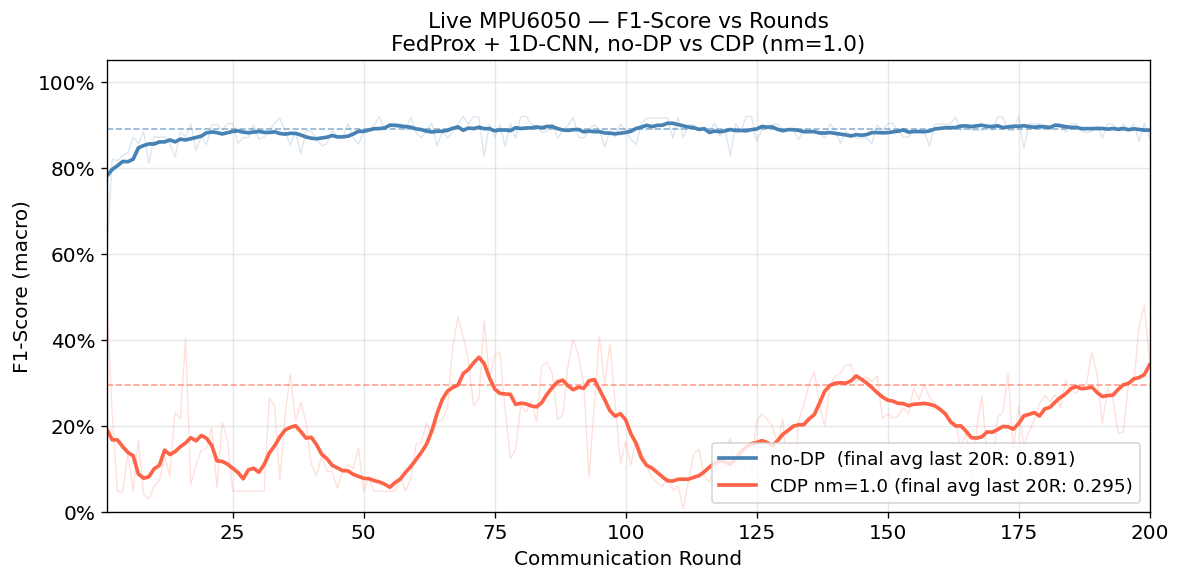

Saved: ../hardware_exp/plot_live_f1_nodp_vs_cdp.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(rounds, nodp['f1'], color='steelblue', alpha=0.2, linewidth=0.8)
ax.plot(cdp['round'], cdp['f1'], color='tomato', alpha=0.2, linewidth=0.8)

ax.plot(rounds, smooth(nodp['f1']), color='steelblue', linewidth=2.2,
        label=f'no-DP  (final avg last 20R: {nodp["f1"].tail(20).mean():.3f})')
ax.plot(cdp['round'], smooth(cdp['f1']), color='tomato', linewidth=2.2,
        label=f'CDP nm=1.0 (final avg last 20R: {cdp["f1"].tail(20).mean():.3f})')

ax.axhline(nodp['f1'].tail(20).mean(), color='steelblue', linestyle='--',
           linewidth=1, alpha=0.6)
ax.axhline(cdp['f1'].tail(20).mean(), color='tomato', linestyle='--',
           linewidth=1, alpha=0.6)

ax.set_xlabel('Communication Round')
ax.set_ylabel('F1-Score (macro)')
ax.set_title('Live MPU6050 — F1-Score vs Rounds\nFedProx + 1D-CNN, no-DP vs CDP (nm=1.0)')
ax.set_xlim(1, 200)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../hardware_exp/plot_live_f1_nodp_vs_cdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../hardware_exp/plot_live_f1_nodp_vs_cdp.png')

## 3. Side-by-side Accuracy + F1 (combined figure)

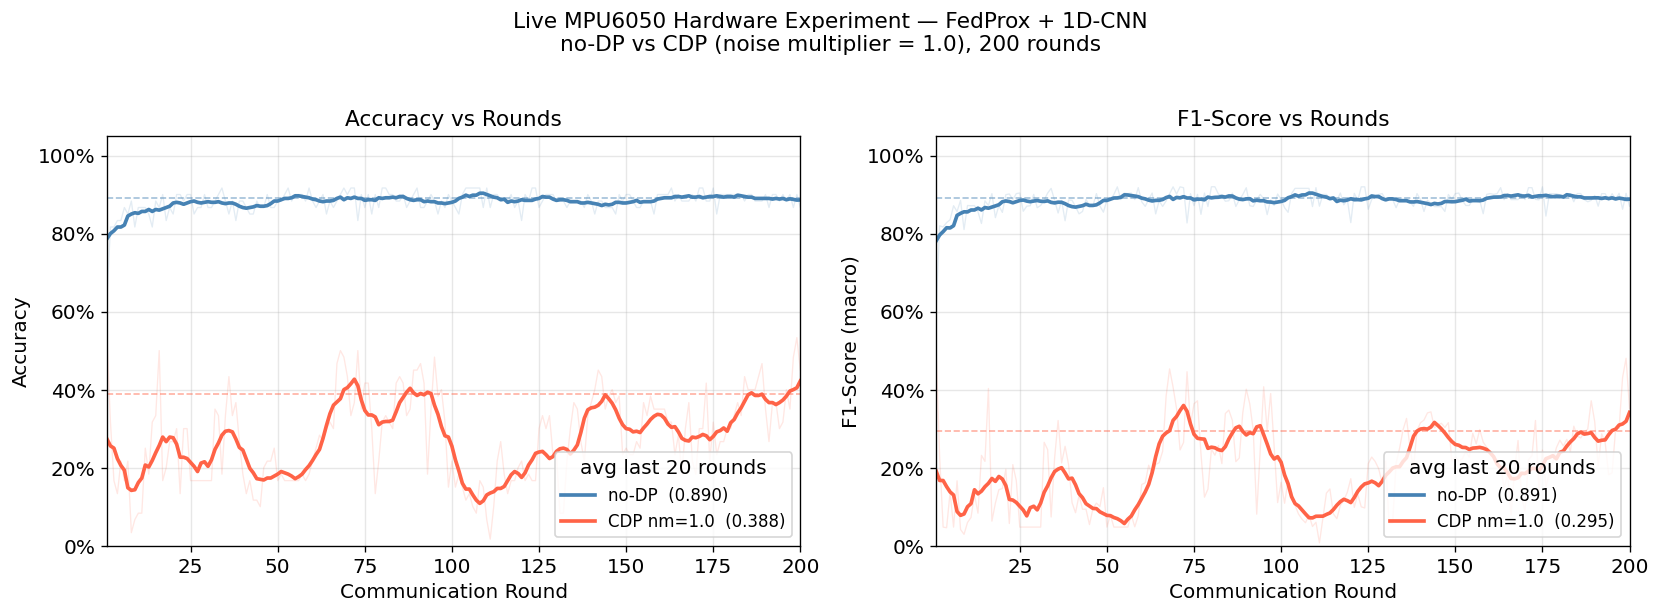

Saved: ../hardware_exp/plot_live_combined_nodp_vs_cdp.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(
    axes,
    ['accuracy', 'f1'],
    ['Accuracy', 'F1-Score (macro)']
):
    ax.plot(rounds, nodp[metric], color='steelblue', alpha=0.15, linewidth=0.8)
    ax.plot(cdp['round'], cdp[metric], color='tomato', alpha=0.15, linewidth=0.8)

    ax.plot(rounds, smooth(nodp[metric]), color='steelblue', linewidth=2.2,
            label=f'no-DP  ({nodp[metric].tail(20).mean():.3f})')
    ax.plot(cdp['round'], smooth(cdp[metric]), color='tomato', linewidth=2.2,
            label=f'CDP nm=1.0  ({cdp[metric].tail(20).mean():.3f})')

    ax.axhline(nodp[metric].tail(20).mean(), color='steelblue',
               linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(cdp[metric].tail(20).mean(), color='tomato',
               linestyle='--', linewidth=1, alpha=0.5)

    ax.set_xlabel('Communication Round')
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, 200)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.legend(title='avg last 20 rounds', loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Accuracy vs Rounds')
axes[1].set_title('F1-Score vs Rounds')
fig.suptitle('Live MPU6050 Hardware Experiment — FedProx + 1D-CNN\nno-DP vs CDP (noise multiplier = 1.0), 200 rounds',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../hardware_exp/plot_live_combined_nodp_vs_cdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../hardware_exp/plot_live_combined_nodp_vs_cdp.png')

## 4. Summary Statistics

In [16]:
summary = pd.DataFrame({
    'Metric': ['Accuracy (Round 1)', 'Accuracy (avg last 20R)', 'Accuracy (max)',
               'F1 (Round 1)', 'F1 (avg last 20R)', 'F1 (max)',
               'Latency ms (avg)', 'CPU % (avg)', 'RAM MB (avg)'],
    'no-DP': [
        f"{nodp['accuracy'].iloc[0]:.4f}",
        f"{nodp['accuracy'].tail(20).mean():.4f}",
        f"{nodp['accuracy'].max():.4f}",
        f"{nodp['f1'].iloc[0]:.4f}",
        f"{nodp['f1'].tail(20).mean():.4f}",
        f"{nodp['f1'].max():.4f}",
        f"{nodp['fit_wall_s'].iloc[1:].mean()*1000:.1f}",
        f"{nodp['cpu_pct'].iloc[1:].mean():.1f}",
        f"{nodp['memory_usage_mb'].iloc[1:].mean():.1f}",
    ],
    'CDP nm=1.0': [
        f"{cdp['accuracy'].iloc[0]:.4f}",
        f"{cdp['accuracy'].tail(20).mean():.4f}",
        f"{cdp['accuracy'].max():.4f}",
        f"{cdp['f1'].iloc[0]:.4f}",
        f"{cdp['f1'].tail(20).mean():.4f}",
        f"{cdp['f1'].max():.4f}",
        f"{cdp['fit_wall_s'].iloc[1:].mean()*1000:.1f}",
        f"{cdp['cpu_pct'].iloc[1:].mean():.1f}",
        f"{cdp['memory_usage_mb'].iloc[1:].mean():.1f}",
    ]
})

print(summary.to_string(index=False))

                 Metric  no-DP CDP nm=1.0
     Accuracy (Round 1) 0.6333     0.5333
Accuracy (avg last 20R) 0.8900     0.3875
         Accuracy (max) 0.9167     0.5333
           F1 (Round 1) 0.6062     0.4961
      F1 (avg last 20R) 0.8913     0.2949
               F1 (max) 0.9199     0.4961
       Latency ms (avg)  910.0      914.9
            CPU % (avg)   84.5       84.4
           RAM MB (avg)  420.0      420.3
